# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-22 15:17:56.702941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 15:17:56.757061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 15:17:58.171209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    f1_score, precision_recall_fscore_support
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [5]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/ADRIATIC_SEA/Audio_data'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA'

#@markdown Path to your single annotation JSON file
annotation_json_path = '/data2/mromaniuc/cet-det/datasets/ADRIATIC_SEA/outputs/annotations.json'  #@param {type:'string'}

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [6]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1776863881.471903 1891263 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


I0000 00:00:1776863881.880546 1891263 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [6]:
#@title Parse annotations and build window list

wav_path = Path(f'{wav_folder}/full_recording.wav')

with open(annotation_json_path) as f:
    annot = json.load(f)

annotations = annot['annotations']

if not wav_path.exists():
    raise FileNotFoundError(f'WAV not found: {wav_path}')

duration = librosa.get_duration(path=str(wav_path))
n_windows = int(duration // window_size_s)

windows = []
for i in range(n_windows):
    win_start = i * window_size_s
    win_end = win_start + window_size_s

    n_clicks = 0
    click_count = 0
    n_whistles = 0
    whistle_subclasses = []

    for ann in annotations:
        overlap = min(win_end, ann['end']) - max(win_start, ann['start'])
        if overlap >= min_overlap_s:
            if ann['label'] == 'click':
                n_clicks += 1
                click_count += ann.get('count', 0)
            elif ann['label'] == 'whistle':
                n_whistles += 1
                subclass = ann.get('subclass', None)
                if subclass is not None:
                    whistle_subclasses.append(subclass)

    # Derive composite label
    has_clicks = n_clicks > 0
    has_whistles = n_whistles > 0
    if has_clicks and has_whistles:
        label = 'click+whistle'
    elif has_clicks:
        label = 'click_only'
    elif has_whistles:
        label = 'whistle_only'
    else:
        label = 'background'

    windows.append({
        'wav_path': str(wav_path),
        'offset_s': win_start,
        'label': label,
        'n_clicks': n_clicks,
        'click_count': click_count,
        'n_whistles': n_whistles,
        'whistle_subclasses': sorted(set(whistle_subclasses)),
    })

windows_df = pd.DataFrame(windows)

print(f'Total windows: {len(windows_df)}')
print(f'Duration: {duration:.1f}s\n')

print('=== Composite label distribution ===')
print(windows_df['label'].value_counts())

print('\n=== Click count stats (click-containing windows) ===')
click_windows = windows_df[windows_df['n_clicks'] > 0]
if len(click_windows):
    print(f'  Windows with clicks: {len(click_windows)}')
    print(f'  Click count per window: mean={click_windows["click_count"].mean():.1f}, '
          f'median={click_windows["click_count"].median():.1f}, '
          f'max={click_windows["click_count"].max()}')

print('\n=== Whistle stats (whistle-containing windows) ===')
whistle_windows = windows_df[windows_df['n_whistles'] > 0]
if len(whistle_windows):
    print(f'  Windows with whistles: {len(whistle_windows)}')
    # Subclass breakdown
    all_subclasses = [s for subs in whistle_windows['whistle_subclasses'] for s in subs]
    if all_subclasses:
        from collections import Counter
        print(f'  Subclass counts: {dict(Counter(all_subclasses))}')

Total windows: 1180
Duration: 5900.2s

=== Composite label distribution ===
label
click_only       702
background       238
click+whistle    194
whistle_only      46
Name: count, dtype: int64

=== Click count stats (click-containing windows) ===
  Windows with clicks: 896
  Click count per window: mean=109.6, median=85.0, max=570

=== Whistle stats (whistle-containing windows) ===
  Windows with whistles: 240
  Subclass counts: {2: 94, 1: 116, 3: 76}


just to check wether we correctly assigned the labels:

In [8]:
#@title Visualize window labels

# Color map for composite labels
label_colors = {
    'background': '#d3d3d3',       # light gray
    'click_only': '#4682b4',       # steelblue
    'whistle_only': '#e67e22',     # orange
    'click+whistle': '#8e44ad',    # purple
}

fig, axes = plt.subplots(2, 1, figsize=(18, 5), gridspec_kw={'height_ratios': [3, 1]})

# --- Top: window labels as colored bars ---
ax = axes[0]
for _, row in windows_df.iterrows():
    color = label_colors.get(row['label'], 'gray')
    ax.barh(0, window_size_s, left=row['offset_s'], height=0.6,
            color=color, edgecolor='white', linewidth=0.2)

# Overlay raw annotations
for ann in annotations:
    ann_color = '#e74c3c' if ann['label'] == 'click' else '#2ecc71'  # red clicks, green whistles
    ax.barh(0.8, ann['end'] - ann['start'], left=ann['start'],
            height=0.15, color=ann_color, alpha=0.7)

ax.set_xlim(0, duration)
ax.set_yticks([0, 0.8])
ax.set_yticklabels(['windows', 'annotations'])
ax.set_title(f'Window labels across full_recording.wav ({len(windows_df)} windows, {duration:.0f}s)')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=label_colors['background'], label='background'),
    Patch(facecolor=label_colors['click_only'], label='click_only'),
    Patch(facecolor=label_colors['whistle_only'], label='whistle_only'),
    Patch(facecolor=label_colors['click+whistle'], label='click+whistle'),
    Patch(facecolor='#e74c3c', label='raw click ann.'),
    Patch(facecolor='#2ecc71', label='raw whistle ann.'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=7, ncol=3)

# --- Bottom: click density per window ---
ax2 = axes[1]
ax2.bar(windows_df['offset_s'], windows_df['click_count'],
        width=window_size_s, color='#4682b4', alpha=0.6, edgecolor='none')
ax2.set_xlim(0, duration)
ax2.set_ylabel('Click count')
ax2.set_xlabel('Time (s)')
ax2.set_title('Click density per window')

plt.tight_layout()
plt.savefig(f'{save_dir}/figures/visualize_windows.png', dpi=150, bbox_inches='tight')
plt.close()
print(f'Saved to {save_dir}/figures/visualize_windows.png')

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/figures/visualize_windows.png


Let s see it more in detail, in 1-min length windows

In [9]:
#@title Visualize window labels in 60s segments

label_colors = {
    'background': '#d3d3d3',
    'click_only': '#4682b4',
    'whistle_only': '#e67e22',
    'click+whistle': '#8e44ad',
}

segment_duration = 60  # seconds per row
n_segments = int(np.ceil(duration / segment_duration))

fig, axes = plt.subplots(n_segments, 1, figsize=(18, 1.2 * n_segments))
if n_segments == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    seg_start = idx * segment_duration
    seg_end = seg_start + segment_duration

    # Draw window labels
    seg_windows = windows_df[(windows_df['offset_s'] >= seg_start) & (windows_df['offset_s'] < seg_end)]
    for _, row in seg_windows.iterrows():
        color = label_colors.get(row['label'], 'gray')
        ax.barh(0, window_size_s, left=row['offset_s'], height=0.6,
                color=color, edgecolor='white', linewidth=0.2)

    # Overlay raw annotations
    for ann in annotations:
        if ann['end'] < seg_start or ann['start'] > seg_end:
            continue
        ann_color = '#e74c3c' if ann['label'] == 'click' else '#2ecc71'
        ax.barh(0.8, ann['end'] - ann['start'], left=ann['start'],
                height=0.15, color=ann_color, alpha=0.7)

    ax.set_xlim(seg_start, seg_end)
    ax.set_yticks([0, 0.8])
    ax.set_yticklabels(['win', 'ann'], fontsize=6)
    ax.set_ylabel(f'{seg_start}s', fontsize=6, rotation=0, labelpad=25)
    ax.tick_params(axis='x', labelsize=6)

    if idx < n_segments - 1:
        ax.set_xticks([])

axes[-1].set_xlabel('Time (s)')
axes[0].set_title(f'Window labels — full_recording.wav ({len(windows_df)} windows, {duration:.0f}s)')

# Legend on first axis
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=label_colors['background'], label='background'),
    Patch(facecolor=label_colors['click_only'], label='click_only'),
    Patch(facecolor=label_colors['whistle_only'], label='whistle_only'),
    Patch(facecolor=label_colors['click+whistle'], label='click+whistle'),
    Patch(facecolor='#e74c3c', label='raw click'),
    Patch(facecolor='#2ecc71', label='raw whistle'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=5, ncol=6)

plt.tight_layout()
plt.savefig(f'{save_dir}/figures/visualize_windows_segments.png', dpi=150, bbox_inches='tight')
plt.close()
print(f'Saved — {n_segments} segments of {segment_duration}s each')

Saved — 99 segments of 60s each


~45 minutes to run for 3290 samples of 5s resampled from 512khz

In [10]:
import soxr
from tqdm import tqdm

embeddings_list, logits_list, labels_list, failed_idx = [], [], [], []
windows_df = windows_df.reset_index(drop=True)

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr)
        target_len = int(window_size_s * sr)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        audio = audio[:target_len].astype(np.float32)

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])
    except Exception as e:
        failed_idx.append(i)
        print(f'  FAILED [{i}] {Path(row["wav_path"]).name} @ {row["offset_s"]:.1f}s — {repr(e)}')
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(windows_df)} embedded...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape: {X.shape}')

  0%|          | 0/1180 [00:00<?, ?it/s]2026-04-21 11:46:42.091252: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f634406dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-21 11:46:42.091296: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-21 11:46:42.412112: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-21 11:46:42.456934: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-21 11:46:43.346148: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-21 11:46:43.615804: I external/local_xla/xla/stream_executor/cuda/subprocess_co

  100/1180 embedded...


 17%|█▋        | 205/1180 [00:17<00:25, 38.44it/s]

  200/1180 embedded...


 26%|██▌       | 305/1180 [00:20<00:22, 38.32it/s]

...

  1000/1180 embedded...


 94%|█████████▎| 1106/1180 [00:41<00:01, 38.06it/s]

  1100/1180 embedded...


100%|██████████| 1180/1180 [00:43<00:00, 27.08it/s]


Done. 1180 embedded, 0 failed.
Embedding shape: (1180, 1536)


In [12]:
#@title Save embeddings and metadata to Drive


os.makedirs(save_dir, exist_ok=True)

# --- Build raw arrays ---
succeeded_mask = [i for i in windows_df.index if i not in set(failed_idx)]
metadata_df = windows_df.loc[succeeded_mask].copy().reset_index(drop=True)
metadata_df['embedding_idx'] = metadata_df.index

# --- NaN diagnostic ---
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any = nan_in_X | nan_in_Z

print('=== NaN DIAGNOSTIC ===')
print(f'Total windows:          {len(X)}')
print(f'Rows with NaN in X:     {nan_in_X.sum()}')
print(f'Rows with NaN in Z:     {nan_in_Z.sum()}')
print(f'Rows with NaN in either:{nan_any.sum()}')

if nan_any.sum() > 0:
    print('\nAffected rows:')
    for idx in np.where(nan_any)[0]:
        label = y[idx]
        wav = Path(metadata_df.iloc[idx]['wav_path']).name
        offset = metadata_df.iloc[idx]['offset_s']
        nan_x = np.isnan(X[idx]).sum()
        nan_z = np.isnan(Z[idx]).sum()
        print(f'  row {idx:5d} | {label:10s} | {wav} @ {offset:.1f}s | NaN in X: {nan_x}, NaN in Z: {nan_z}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}% of data) — safe to drop, proceeding.')
        valid = ~nan_any
        X_save = X[valid]
        Z_save = Z[valid]
        y_save = y[valid]
        metadata_save = metadata_df[valid].reset_index(drop=True)
        metadata_save['embedding_idx'] = metadata_save.index
    else:
        print(f'\nWARNING: {pct:.2f}% of data has NaN — too many to drop safely, investigate first.')
        print('Saving anyway with NaNs so you do not lose data — fix before training.')
        X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df
else:
    print('\nNo NaN values found — data is clean.')
    X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy', Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy', y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir} ===')
print(f'  X_embeddings.npy  — {X_save.shape}')
print(f'  Z_logits.npy      — {Z_save.shape}')
print(f'  y_labels.npy      — {y_save.shape}')
print(f'  metadata.csv      — {len(metadata_save)} rows')
print(f'\nClass distribution in saved data:')
print(pd.Series(y_save).value_counts())

=== NaN DIAGNOSTIC ===
Total windows:          1180
Rows with NaN in X:     0
Rows with NaN in Z:     0
Rows with NaN in either:0

No NaN values found — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA ===
  X_embeddings.npy  — (1180, 1536)
  Z_logits.npy      — (1180, 14795)
  y_labels.npy      — (1180,)
  metadata.csv      — 1180 rows

Class distribution in saved data:
click_only       702
background       238
click+whistle    194
whistle_only      46
Name: count, dtype: int64


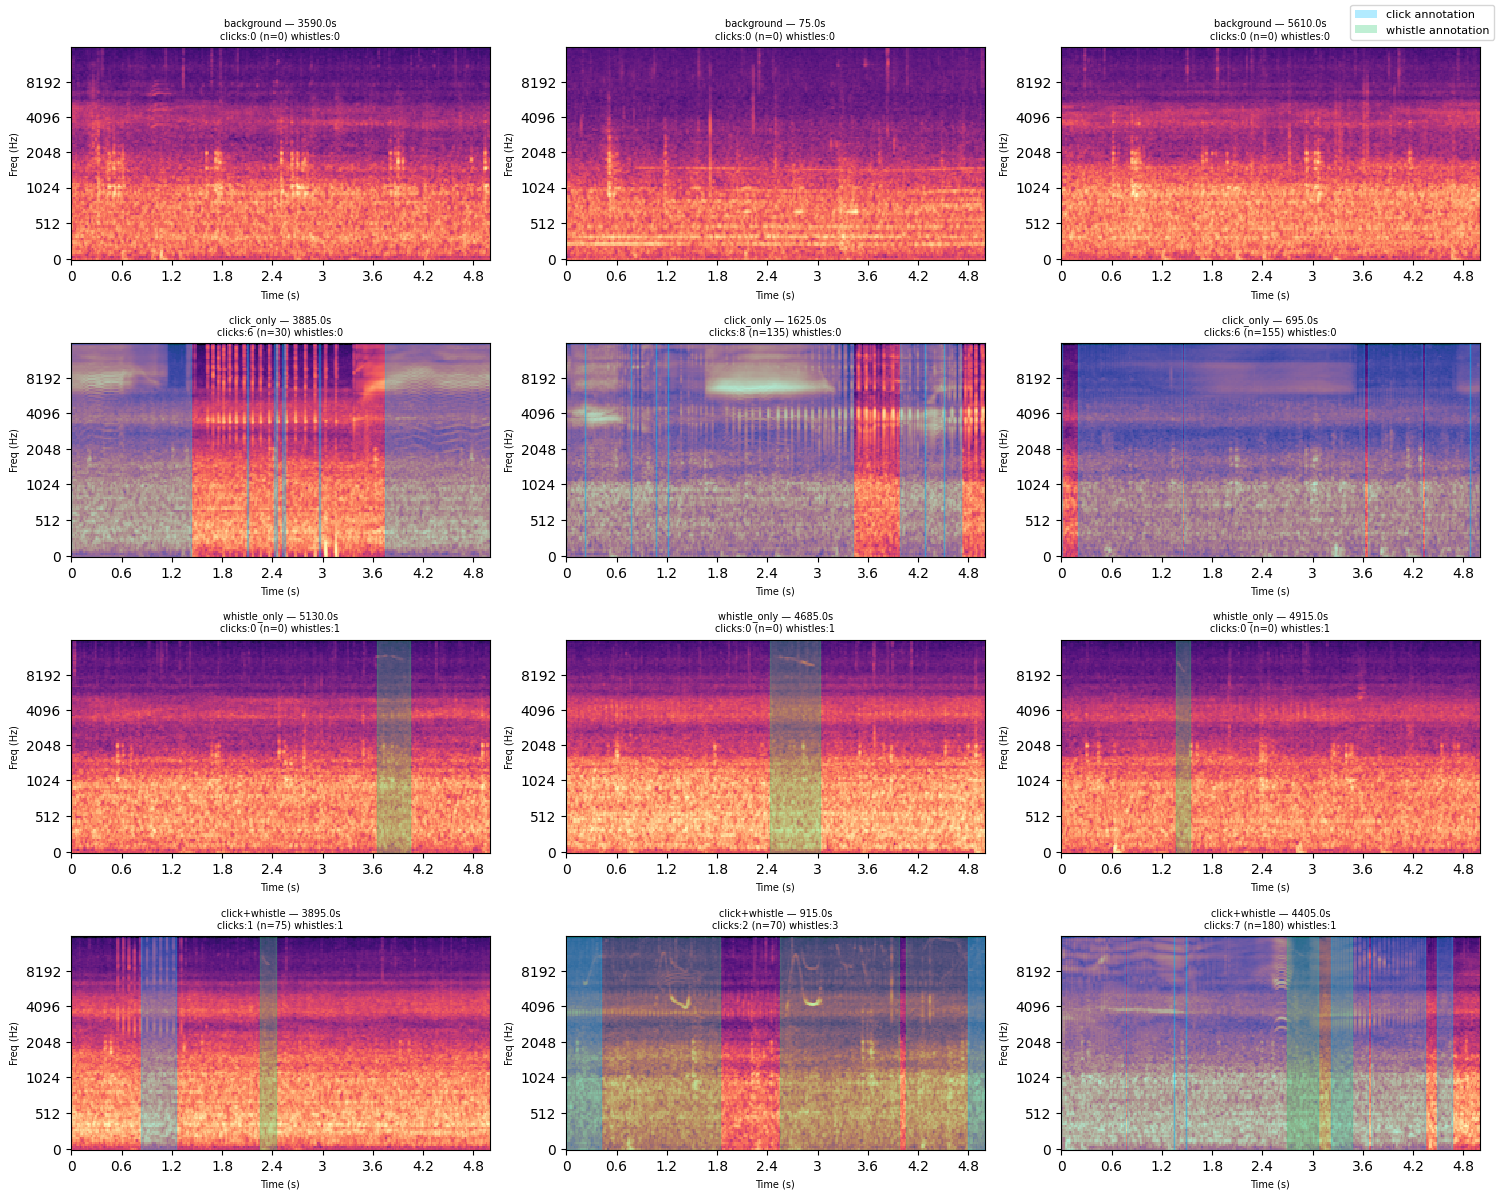

In [16]:
#@title Visualize example spectrograms (4-class)

labels = ['background', 'click_only', 'whistle_only', 'click+whistle']
n_examples = 3

fig, axes = plt.subplots(len(labels), n_examples, figsize=(15, 12))

for row_idx, label in enumerate(labels):
    subset = windows_df[windows_df['label'] == label]
    n_avail = min(n_examples, len(subset))
    samples = subset.sample(n_avail, random_state=42)

    for col_idx in range(n_examples):
        ax = axes[row_idx][col_idx]
        if col_idx >= n_avail:
            ax.axis('off')
            continue

        row = samples.iloc[col_idx]
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr)

        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=sr // 2)
        S_db = librosa.power_to_db(S, ref=np.max)

        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)

        # Overlay raw annotations within this window
        win_start = row['offset_s']
        win_end = win_start + window_size_s
        for ann in annotations:
            if ann['end'] < win_start or ann['start'] > win_end:
                continue
            a_start = max(ann['start'], win_start) - win_start
            a_end = min(ann['end'], win_end) - win_start
            if a_end > a_start:
                color = '#00bfff' if ann['label'] == 'click' else '#2ecc71'
                ax.axvspan(a_start, a_end, color=color, alpha=0.3)

        ax.set_title(f'{label} — {row["offset_s"]:.1f}s'
                     f'\nclicks:{row["n_clicks"]} (n={row["click_count"]}) '
                     f'whistles:{row["n_whistles"]}', fontsize=7)
        ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('Freq (Hz)', fontsize=7)

# Legend
from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#00bfff', alpha=0.3, label='click annotation'),
    Patch(facecolor='#2ecc71', alpha=0.3, label='whistle annotation'),
], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{save_dir}/figures/example_spectrograms_4class.png', dpi=150, bbox_inches='tight')
plt.show()

# retrieving the data and performing zero-shot and fully-supervised classifications

In [7]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   # (9209,)
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   # (9209,)

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (1180, 1536), Z: (1180, 14795), y: (1180,)
Class distribution:
click_only       702
background       238
click+whistle    194
whistle_only      46
Name: count, dtype: int64


In [8]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphin', 'cetacea']):
        print(name)

print("\n--- Water/noise/background ---")
for name in perch_class_names:
    if any(term in name.lower() for term in ['water', 'noise', 'background', 'ambient', 'silence', 'rain', 'wave', 'ocean', 'sea']):
        print(name)

Colibri delphinae
Delphinapterus leucas
Myzomela adolphinae
Phylloscopus whistleri
Tursiops truncatus

--- Water/noise/background ---
Anstisia rosea
Anthus roseatus
Ardenna grisea
Boat_and_Water_vehicle
Cinnyris osea
Conocephalus oceanicus
Coracina caeruleogrisea
Ducula oceanica
Formicivora grisea
Gull_and_seagull
Lycalopex grisea
Microwave_oven
Myiagra oceanica
Myopsalta waterhousei
Myrmotherula grisea
Ocean
Oceanites gracilis
Oceanites oceanicus
Oceanites pincoyae
Petroica rosea
Platycleis grisea
Poecilimon ukrainicus
Prioniturus waterstradti
Psittacula roseata
Rain
Raindrop
Rhodinocichla rosea
Rhodostethia rosea
Sarothrura watersi
Streptopelia roseogrisea
Tachycineta euchrysea
Tamasa rainbowi
Teleogryllus oceanicus
Thalurania watertonii
Traffic_noise_and_roadway_noise
Train
Water
Water_tap_and_faucet
Waves_and_surf
Zoothera talaseae


In [9]:
#@title Zero-shot species analysis — what does Perch think your sounds are? (4-class)

class_names_list = list(embedding_model.class_list['labels'].classes)

# Masks for all 4 classes
masks = {
    'click_only': y_clean == 'click_only',
    'whistle_only': y_clean == 'whistle_only',
    'click+whistle': y_clean == 'click+whistle',
    'background': y_clean == 'background',
}

# Mean logits per class
mean_logits = {label: Z_clean[mask].mean(axis=0) for label, mask in masks.items() if mask.sum() > 0}

# Print top 20 for each
for label, logits in mean_logits.items():
    top_idx = np.argsort(logits)[::-1][:20]
    print(f'TOP 20 PERCH CLASSES FOR {label.upper()} WINDOWS (n={masks[label].sum()}):')
    print('-' * 50)
    for idx in top_idx:
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}')
    print()

# --- Candidate comparison ---

dolphin_candidates = {
    'Tursiops truncatus': class_names_list.index('Tursiops truncatus'),
    'Delphinapterus leucas': class_names_list.index('Delphinapterus leucas'),
}

background_candidates = {
    'Water': class_names_list.index('Water'),
    'Ocean': class_names_list.index('Ocean'),
    'Boat_and_Water_vehicle': class_names_list.index('Boat_and_Water_vehicle'),
}

# Biological classes comparison
print('DOLPHIN CANDIDATES — mean logit across all label types:')
print('-' * 90)
header = f'  {"Species":30s}'
for label in mean_logits:
    header += f'  {label:>15s}'
print(header)
print('-' * 90)
for name, idx in dolphin_candidates.items():
    row = f'  {name:30s}'
    for label, logits in mean_logits.items():
        rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
        row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
    print(row)

print()

# Background classes comparison
print('BACKGROUND CANDIDATES — mean logit across all label types:')
print('-' * 90)
header = f'  {"Class":30s}'
for label in mean_logits:
    header += f'  {label:>15s}'
print(header)
print('-' * 90)
for name, idx in background_candidates.items():
    row = f'  {name:30s}'
    for label, logits in mean_logits.items():
        rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
        row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
    print(row)

TOP 20 PERCH CLASSES FOR CLICK_ONLY WINDOWS (n=702):
--------------------------------------------------
   7.114  Lithobates sylvaticus
   5.878  Domestic_sounds_and_home_sounds
   5.423  Limnodynastes tasmaniensis
   5.317  Vehicle
   5.174  Mechanisms
   5.042  Locustella luscinioides
   4.995  Branta bernicla
   4.981  Nemobius sylvestris
   4.979  Animal
   4.806  Pseudacris maculata
   4.618  Bicycle
   4.609  Tools
   4.595  Fringilla coelebs
   4.584  Phasianus colchicus
   4.566  Corvus brachyrhynchos
   4.558  Corvus cornix
   4.528  Corvus corax
   4.480  Strix varia
   4.475  Lithobates sphenocephalus
   4.473  Wild_animals

TOP 20 PERCH CLASSES FOR WHISTLE_ONLY WINDOWS (n=46):
--------------------------------------------------
   7.972  Lithobates sylvaticus
   6.741  Limnodynastes tasmaniensis
   5.988  Branta bernicla
   5.588  Corvus brachyrhynchos
   5.568  Corvus corax
   5.542  Phasianus colchicus
   5.516  Molothrus ater
   5.415  Corvus cornix
   5.365  Limnodynaste

In [10]:
#@title Train / test split
le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_clean, y_enc, Z_clean,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes: ['background', 'click+whistle', 'click_only', 'whistle_only']
Train: 826  |  Test: 354


Tursiops truncatus was a little bit higher up in the ranking, so we are going to use it as a proxy for delphinid presence

In [11]:
#@title Zero-shot evaluation (Perch V2 built-in logits)
#@markdown Maps biological labels to dolphin species, background to environmental sounds.
#@markdown click+whistle maps to the same dolphin class since Perch doesn't distinguish.

label_to_perch = {
    'click_only': 'Tursiops truncatus',
    'whistle_only': 'Tursiops truncatus',
    'click+whistle': 'Tursiops truncatus',
    'background': 'Water',
}

print('Label → Perch V2 class mapping:')
for cls in class_names:
    mapped = label_to_perch.get(cls, None)
    status = '✓' if mapped else '✗ NOT FOUND'
    print(f'  {cls:30s} → {str(mapped):40s} {status}')

def zero_shot_predict(Z_subset):
    preds = []
    for logits in Z_subset:
        scores = {}
        for cls in class_names:
            pname = label_to_perch.get(cls)
            if pname and pname in perch_class_names:
                scores[cls] = logits[perch_class_names.index(pname)]
            else:
                scores[cls] = -np.inf
        preds.append(max(scores, key=scores.get))
    return le.transform(preds)

y_pred_zs = zero_shot_predict(Z_test)

print('\n' + '=' * 60)
print('ZERO-SHOT (Perch V2 built-in logits)')
print('=' * 60)
print(classification_report(y_test, y_pred_zs, target_names=class_names))

Label → Perch V2 class mapping:
  background                     → Water                                    ✓
  click+whistle                  → Tursiops truncatus                       ✓
  click_only                     → Tursiops truncatus                       ✓
  whistle_only                   → Tursiops truncatus                       ✓

ZERO-SHOT (Perch V2 built-in logits)
               precision    recall  f1-score   support

   background       0.20      1.00      0.33        71
click+whistle       0.00      0.00      0.00        58
   click_only       0.00      0.00      0.00       211
 whistle_only       0.00      0.00      0.00        14

     accuracy                           0.20       354
    macro avg       0.05      0.25      0.08       354
 weighted avg       0.04      0.20      0.07       354



/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Multi-class handling: 4 classes, unbalanced

In [12]:
#@title Train classifiers + track metrics (4-class)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = clf.score(X_train_sc, y_train)
    test_acc = clf.score(X_test_sc, y_test)

    # Multiclass ROC AUC — one-vs-rest, weighted by support
    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Per-class F1
    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# Summary
print('\n' + '=' * 100)
print('SUMMARY — 4-CLASS EVALUATION')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

# Per-class breakdown across all classifiers
print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>15s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>15.4f}'
    print(row)


Training Logistic Regression...


/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Time: 0.4s | Train: 1.0000 | Test: 0.6864 | Macro F1: 0.6123 | ROC AUC (OVR): 0.8330
               precision    recall  f1-score   support

   background       0.59      0.61      0.60        71
click+whistle       0.53      0.55      0.54        58
   click_only       0.76      0.77      0.76       211
 whistle_only       0.75      0.43      0.55        14

     accuracy                           0.69       354
    macro avg       0.66      0.59      0.61       354
 weighted avg       0.69      0.69      0.69       354

  Per-class F1:
    background           0.5972
    click+whistle        0.5424
    click_only           0.7642
    whistle_only         0.5455

Training Decision Tree...
  Time: 1.1s | Train: 0.9552 | Test: 0.6554 | Macro F1: 0.5267 | ROC AUC (OVR): 0.6926
               precision    recall  f1-score   support

   background       0.61      0.66      0.64        71
click+whistle       0.38      0.40      0.39        58
   click_only       0.75      0.75      0.75  

/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

  Time: 2.5s | Train: 0.8862 | Test: 0.7429 | Macro F1: 0.6080 | ROC AUC (OVR): 0.8650
               precision    recall  f1-score   support

   background       0.57      0.93      0.71        71
click+whistle       0.75      0.47      0.57        58
   click_only       0.84      0.79      0.81       211
 whistle_only       0.75      0.21      0.33        14

     accuracy                           0.74       354
    macro avg       0.73      0.60      0.61       354
 weighted avg       0.77      0.74      0.74       354

  Per-class F1:
    background           0.7097
    click+whistle        0.5745
    click_only           0.8146
    whistle_only         0.3333

SUMMARY — 4-CLASS EVALUATION
Classifier           Macro F1  AUC OVR    Train     Test    Gap   Time
----------------------------------------------------------------------------------------------------
Logistic Regression    0.6123   0.8330   1.0000   0.6864 0.3136    0.4s
SVM (RBF)              0.6080   0.8650   0.8862   0.

We have way to litte samples for the wistle_only class so the algorithms are breaking, not even class reweighting is helping in this case, so we will merge whistle_only and click+whistle -> whistle present

In [13]:
#@title Merge whistle classes + train/test split

# Remap whistle_only and click+whistle → whistle_present
label_remap = {
    'background': 'background',
    'click_only': 'click_only',
    'whistle_only': 'whistle_present',
    'click+whistle': 'whistle_present',
}
y_merged = np.array([label_remap[label] for label in y_clean])

le = LabelEncoder()
y_enc = le.fit_transform(y_merged)
class_names = list(le.classes_)
print('Classes:', class_names)
print('Distribution:', dict(zip(*np.unique(y_merged, return_counts=True))))

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_clean, y_enc, Z_clean,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print('Train distribution:', dict(zip(class_names, np.bincount(y_train))))
print('Test distribution:', dict(zip(class_names, np.bincount(y_test))))

Classes: ['background', 'click_only', 'whistle_present']
Distribution: {'background': 238, 'click_only': 702, 'whistle_present': 240}
Train: 826  |  Test: 354
Train distribution: {'background': 167, 'click_only': 491, 'whistle_present': 168}
Test distribution: {'background': 71, 'click_only': 211, 'whistle_present': 72}


In [14]:
#@title Train classifiers + track metrics (3-class)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = clf.score(X_train_sc, y_train)
    test_acc = clf.score(X_test_sc, y_test)

    # Multiclass ROC AUC — one-vs-rest, weighted by support
    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Per-class F1
    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# Summary
print('\n' + '=' * 100)
print('SUMMARY — 4-CLASS EVALUATION')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

# Per-class breakdown across all classifiers
print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>15s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>15.4f}'
    print(row)


Training Logistic Regression...


/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Time: 0.3s | Train: 1.0000 | Test: 0.7373 | Macro F1: 0.6946 | ROC AUC (OVR): 0.8355
                 precision    recall  f1-score   support

     background       0.57      0.66      0.61        71
     click_only       0.80      0.81      0.80       211
whistle_present       0.75      0.60      0.67        72

       accuracy                           0.74       354
      macro avg       0.71      0.69      0.69       354
   weighted avg       0.74      0.74      0.74       354

  Per-class F1:
    background           0.6144
    click_only           0.8028
    whistle_present      0.6667

Training Decision Tree...
  Time: 1.0s | Train: 0.9286 | Test: 0.7006 | Macro F1: 0.6727 | ROC AUC (OVR): 0.7799
                 precision    recall  f1-score   support

     background       0.60      0.75      0.66        71
     click_only       0.81      0.71      0.75       211
whistle_present       0.57      0.64      0.60        72

       accuracy                           0.70       35

In [15]:
#@title PyTorch MLP with Dropout (3-class)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import numpy as np
import copy
import time

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
}

n_classes = len(class_names)

# ── Model builder (multiclass) ───────────────────────────────────────────────
def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

# ── Data prep ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Classes: {class_names}')
print(f'Train distribution: {dict(zip(class_names, np.bincount(y_train)))}')
print(f'Test distribution:  {dict(zip(class_names, np.bincount(y_test)))}')

# Class weights for loss
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    [class_counts.sum() / (n_classes * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')

# ── Training loop ─────────────────────────────────────────────────────────────
mlp_results  = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'], n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss  = float('inf')
    patience_counter = 0
    best_state     = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch     = 0
    early_stopped  = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)

            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_per_class = f1_score(y_test, test_pred, average=None, labels=range(n_classes))
    test_acc     = accuracy_score(y_test, test_pred)

    try:
        auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs':   train_accs,   'val_accs':   val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC OVR: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print('PyTorch MLP SUMMARY (3-class)')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} '
      f'{"Test":>8} {"Gap":>6} {"Epochs":>7} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Using device: cuda
Classes: ['background', 'click_only', 'whistle_present']
Train distribution: {'background': 167, 'click_only': 491, 'whistle_present': 168}
Test distribution:  {'background': 71, 'click_only': 211, 'whistle_present': 72}
Class weights: {'background': 1.649, 'click_only': 0.561, 'whistle_present': 1.639}

Training PyTorch MLP (128) drop=0.4...
  Epochs: 76 | Best: 46 | Early stop: True
  Time: 1.1s | Train Acc: 0.9402 | Test Acc: 0.7768 | Macro F1: 0.7550 | AUC OVR: 0.8583
                 precision    recall  f1-score   support

     background       0.57      0.89      0.70        71
     click_only       0.87      0.78      0.82       211
whistle_present       0.87      0.65      0.75        72

       accuracy                           0.78       354
      macro avg       0.77      0.77      0.76       354
   weighted avg       0.81      0.78      0.78       354

  Per-class F1:
    background           0.6961
    click_only           0.8229
    whistle_present   

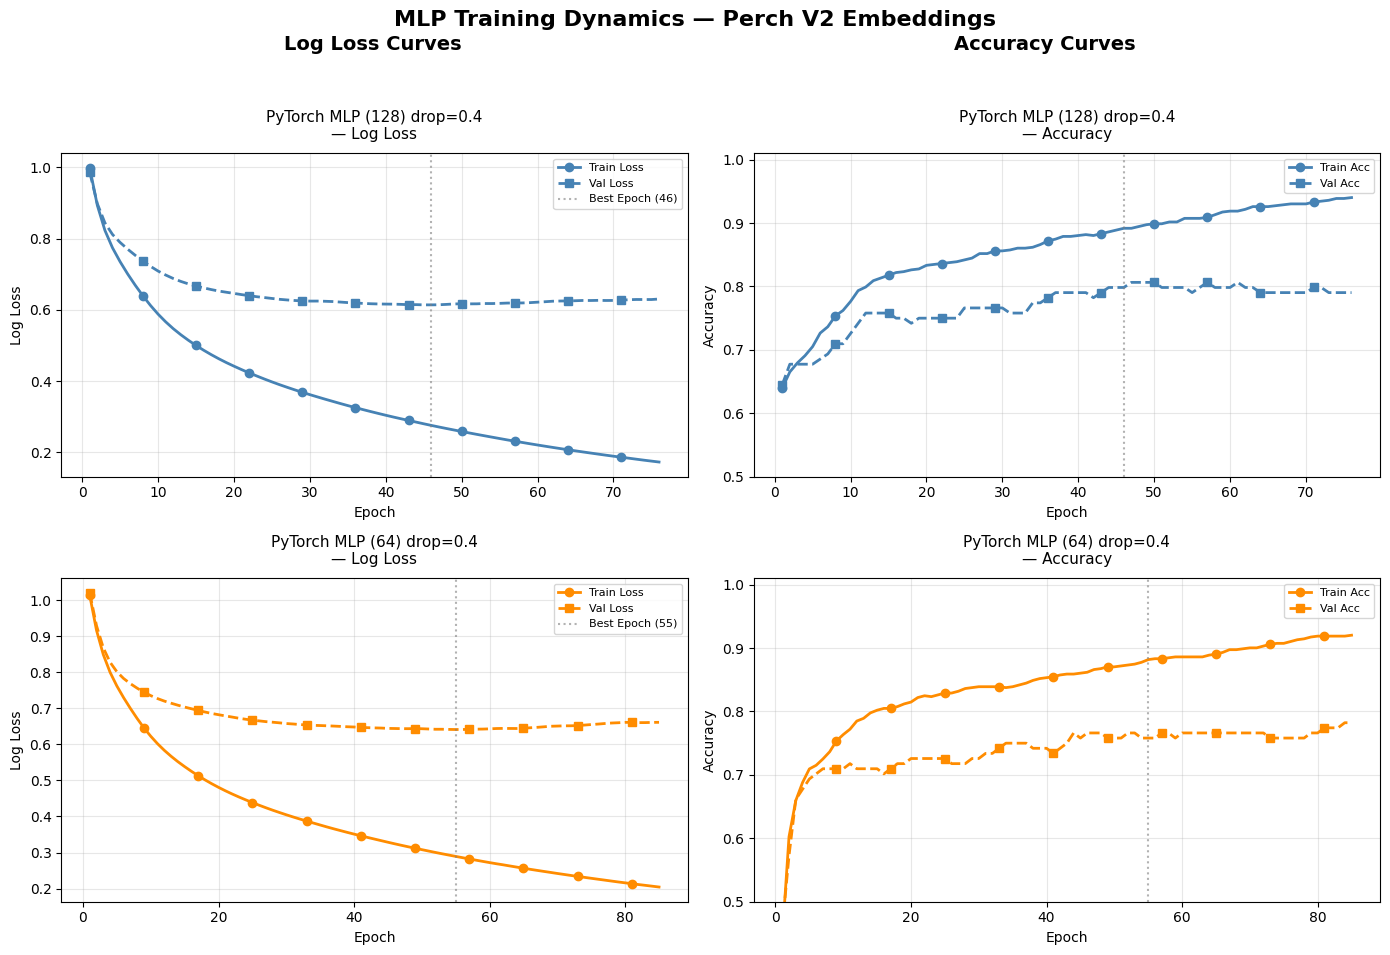

In [16]:
import matplotlib.pyplot as plt
import numpy as np

color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

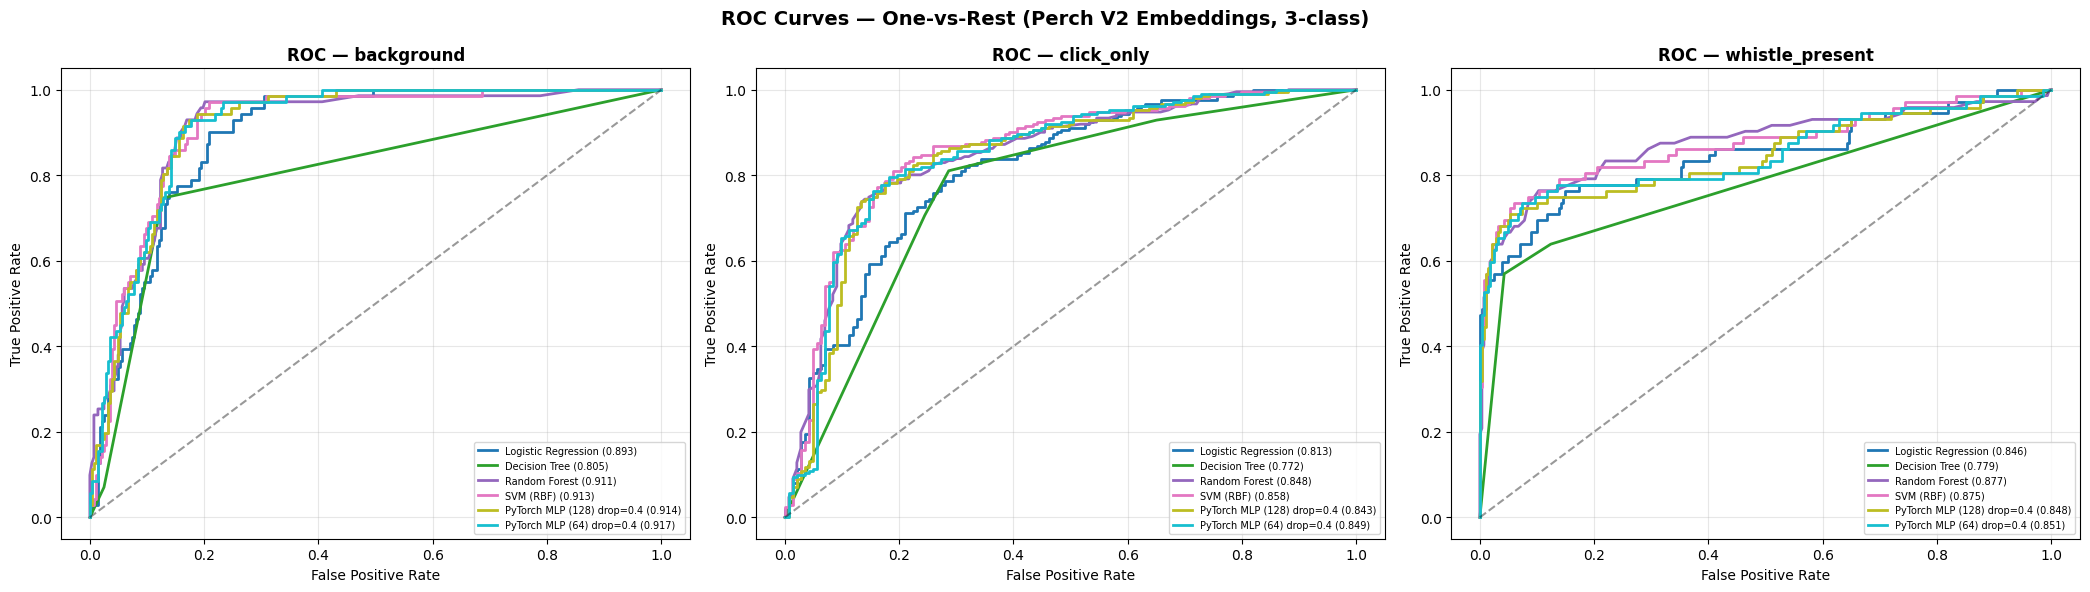

In [17]:
#@title ROC Curves — ALL Classifiers (3-class, one-vs-rest)
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

fig, axes = plt.subplots(1, len(class_names), figsize=(7 * len(class_names), 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for class_idx, (cn, ax) in enumerate(zip(class_names, axes)):
    for model_idx, (name, res) in enumerate(results.items()):
        if 'y_proba' not in res:
            continue
        proba = res['y_proba']
        if proba.ndim == 1:
            continue

        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        auc = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
        ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=colors[model_idx], linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {cn}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest (Perch V2 Embeddings, 3-class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/roc_curves_3class.png', dpi=150, bbox_inches='tight')
plt.show()

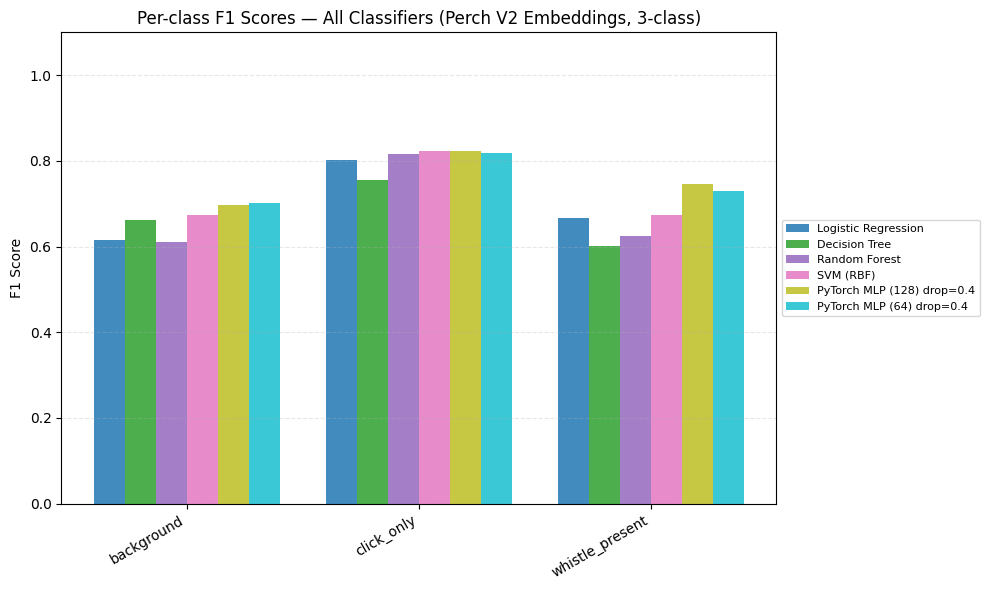

In [18]:
#@title Per-class F1 comparison bar chart — ALL classifiers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

classifier_names = list(results.keys())
n_classifiers = len(classifier_names)
n_classes = len(class_names)

colors = plt.cm.tab10(np.linspace(0, 1, min(n_classifiers, 10)))
x = np.arange(n_classes)
width = 0.8 / n_classifiers

fig, ax = plt.subplots(figsize=(max(10, n_classes * 1.5), 6))

for i, (name, res) in enumerate(results.items()):
    f1_per_class = f1_score(y_test, res['y_pred'],
                            labels=list(range(n_classes)), average=None, zero_division=0)
    offset = (i - n_classifiers / 2 + 0.5) * width
    ax.bar(x + offset, f1_per_class, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (Perch V2 Embeddings, 3-class)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers.png', dpi=150, bbox_inches='tight')
plt.show()

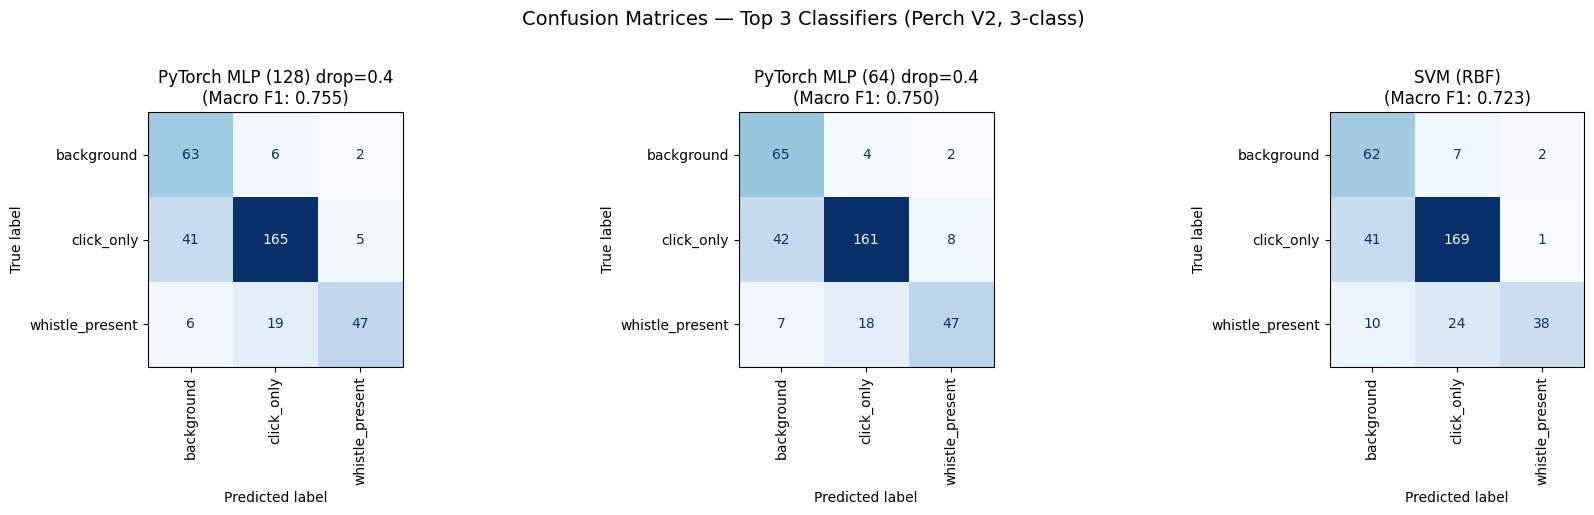

In [19]:
#@title Confusion matrices — Top N classifiers by Macro F1
from sklearn.metrics import ConfusionMatrixDisplay

TOP_N = 3
top_classifiers = sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(6 * TOP_N, 5))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_classifiers):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues'
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})')

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (Perch V2, 3-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#@title Save full results to CSV — ALL classifiers
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import pandas as pd

rows = []
for name, res in results.items():
    # Multiclass ROC AUC
    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': auc,
        'time_seconds': res['time_s'],
    }
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall'] = round(r[i], 3)
        row[f'{cls}_f1'] = round(f[i], 3)
        row[f'{cls}_support'] = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
cols = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds'] + \
       [c for c in results_df.columns if c not in ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']]
results_df = results_df[cols]

results_df.to_csv(f'{save_dir}/perch_v2_all_classifiers_results.csv', index=False)
print(f'Saved {len(results_df)} classifiers to {save_dir}/perch_v2_all_classifiers_results.csv')
display(results_df.round(3))

Saved 6 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/perch_v2_all_classifiers_results.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,background_precision,background_recall,background_f1,background_support,click_only_precision,click_only_recall,click_only_f1,click_only_support,whistle_present_precision,whistle_present_recall,whistle_present_f1,whistle_present_support
0,Logistic Regression,0.695,0.836,0.284,0.573,0.662,0.614,71,0.795,0.810,0.803,211,0.754,0.597,0.667,72
1,Decision Tree,0.673,0.780,1.048,0.596,0.746,0.662,71,0.810,0.706,0.754,211,0.568,0.639,0.601,72
2,Random Forest,0.683,0.866,0.896,0.614,0.606,0.610,71,0.757,0.886,0.817,211,0.919,0.472,0.624,72
3,SVM (RBF),0.723,0.872,2.249,0.549,0.873,0.674,71,0.845,0.801,0.822,211,0.927,0.528,0.673,72
4,PyTorch MLP (128) drop=0.4,0.755,0.858,1.096,0.573,0.887,0.696,71,0.868,0.782,0.823,211,0.870,0.653,0.746,72
5,PyTorch MLP (64) drop=0.4,0.750,0.863,1.207,0.570,0.915,0.703,71,0.880,0.763,0.817,211,0.825,0.653,0.729,72


Running full PCA...



Total components: 1180

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 19.7901         19.7901
      PC2                  5.6495         25.4396
      PC3                  4.9425         30.3821
      PC4                  3.8456         34.2276
      PC5                  2.8538         37.0814
      PC6                  2.1968         39.2782
      PC7                  1.9560         41.2342
      PC8                  1.8213         43.0555
      PC9                  1.6886         44.7441
     PC10                  1.5273         46.2714
     PC11                  1.3613         47.6327
     PC12                  1.2492         48.8819
     PC13                  1.1457         50.0276
     PC14                  1.0445         51.0721
     PC15                  0.9897         52.0618
     PC16                  0.9082         52.9699
     PC17                  0.8559         53.8258
     PC18                  0.

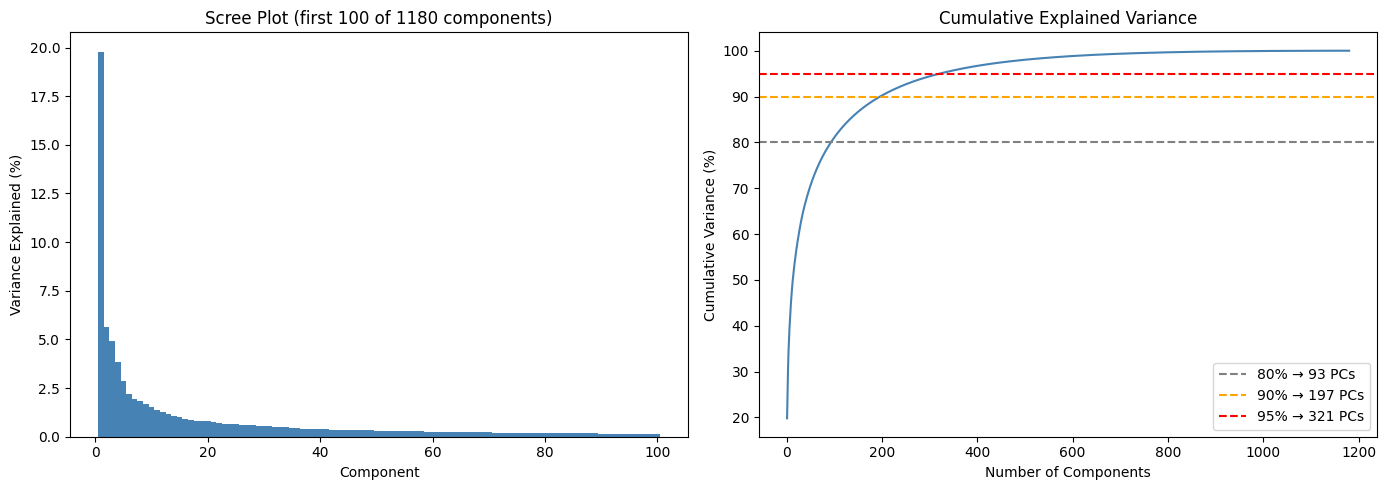

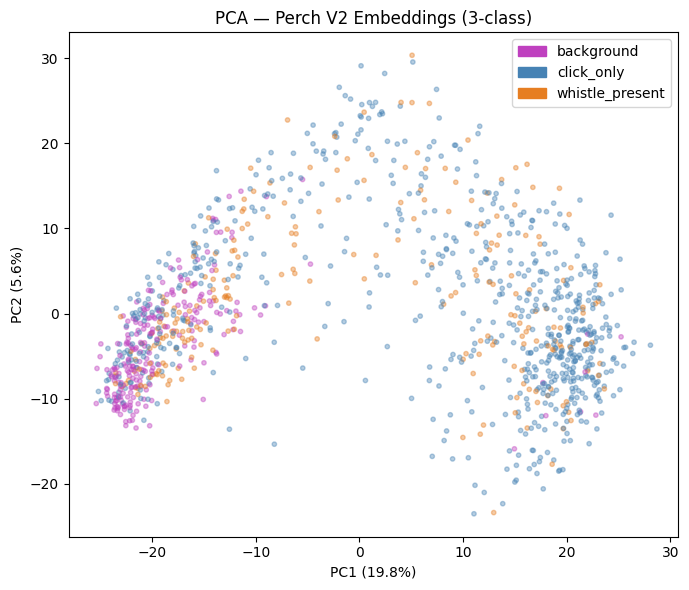


PCA-reduced shape for t-SNE/UMAP input: (1180, 197)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


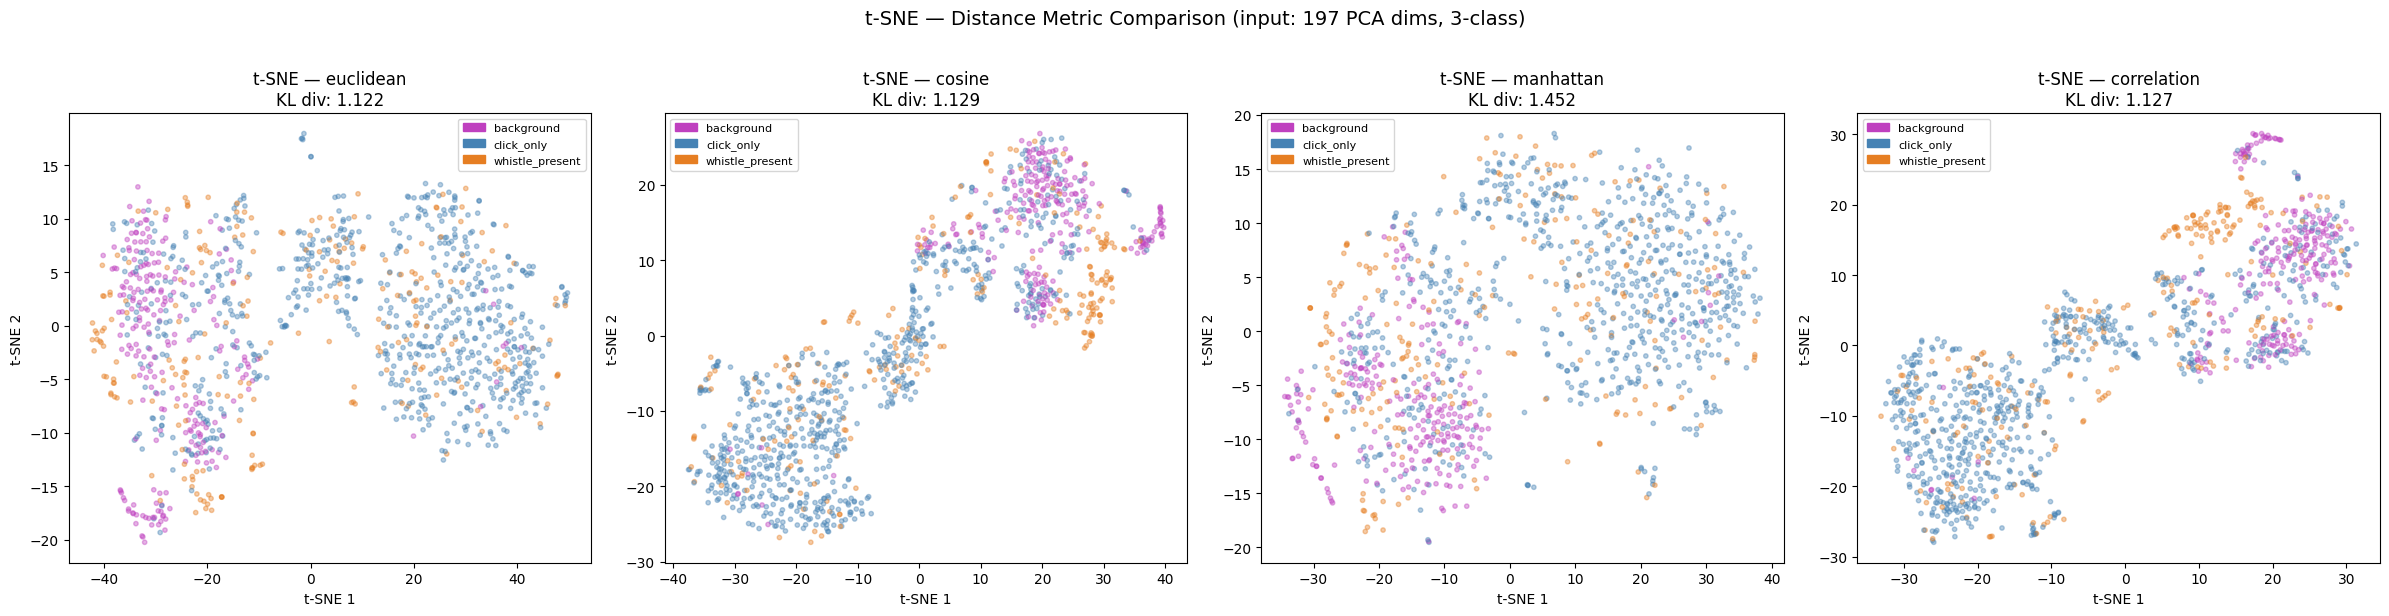


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


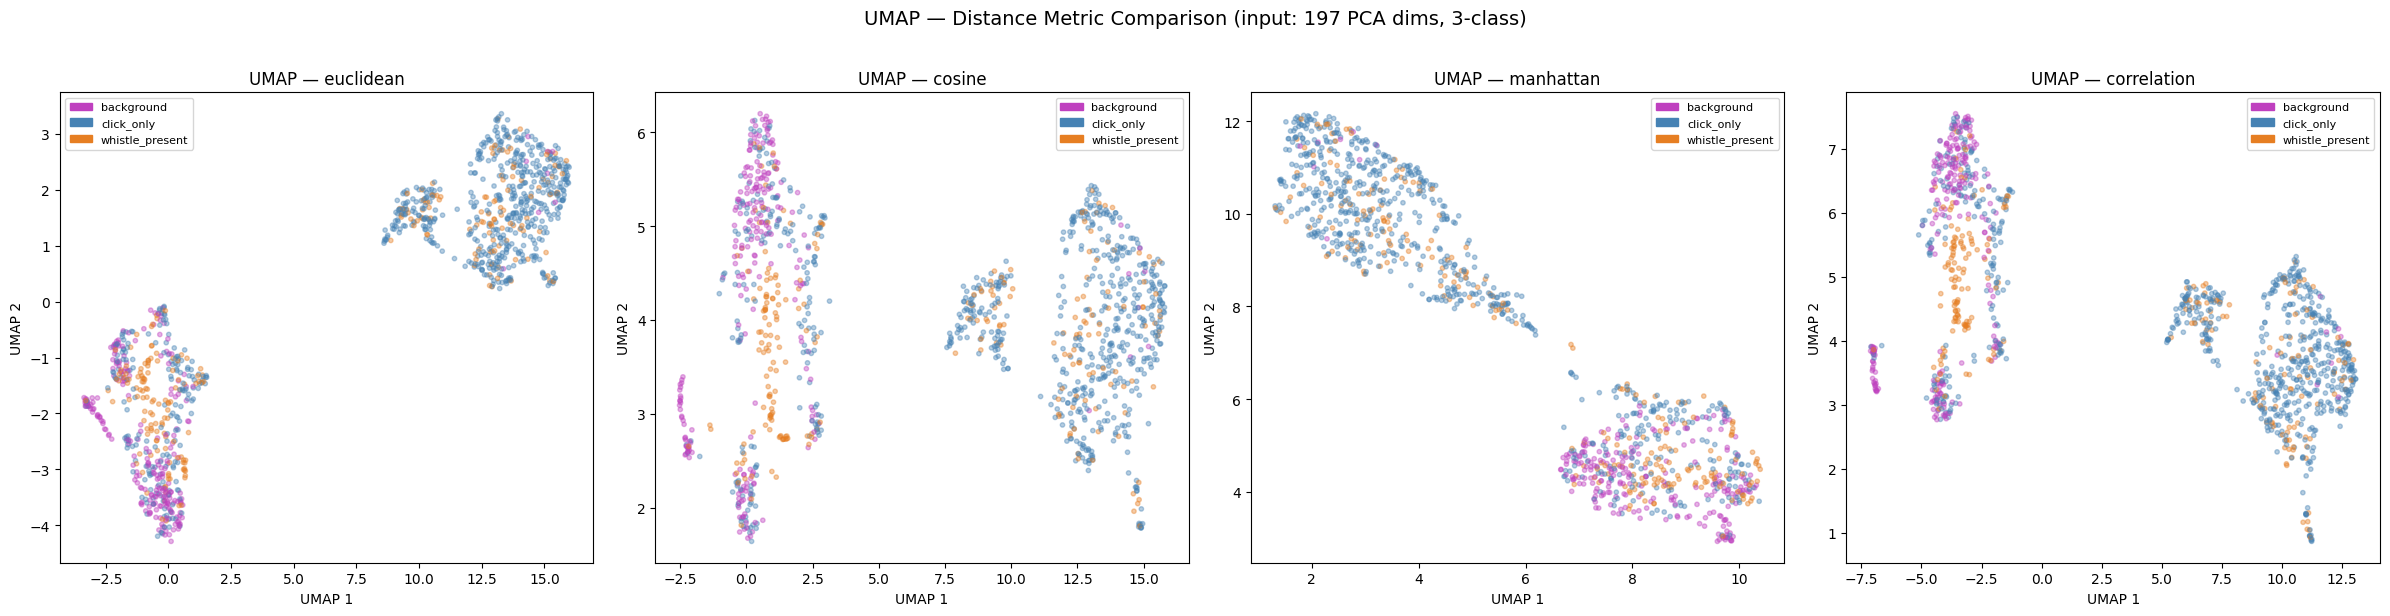


SUMMARY
PCA input dims: 1536 → reduced to 197 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  euclidean        KL: 1.1224
  correlation      KL: 1.1265
  cosine           KL: 1.1292
  manhattan        KL: 1.4524

All coordinates saved.


In [36]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (3-class)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — 3 classes
colors = {
    'background': '#BF40BF',
    'click_only': '#4682b4',
    'whistle_present': '#e67e22',
}
c = np.array([colors[label_remap[label]] for label in y_clean])
alpha = 0.4
s = 10
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = np.argmax(cumvar_full >= 80) + 1
n90 = np.argmax(cumvar_full >= 90) + 1
n95 = np.argmax(cumvar_full >= 95) + 1
n99 = np.argmax(cumvar_full >= 99) + 1
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray', linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red', linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings (3-class)')
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison (input: {n_pca} PCA dims, 3-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison (input: {n_pca} PCA dims, 3-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

# Save all coordinates
np.save(f'{save_dir}/dim_red/coords_pca2.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}.npy', tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}.npy', umap_results[metric])
print('\nAll coordinates saved.')

In [37]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRICS')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

y_numeric = np.array([0 if label == 'background' else 1 for label in y_clean])

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_numeric)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_numeric)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_numeric)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRICS
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9484       0.2006
t-SNE                cosine                    0.9523       0.2127
t-SNE                manhattan                 0.9333       0.1645
t-SNE                correlation               0.9538       0.2219

UMAP                 euclidean                 0.9306       0.2363
UMAP                 cosine                    0.9387       0.2326
UMAP                 manhattan                 0.9136       0.1926
UMAP                 correlation               0.9381       0.2373

PCA (2D)             euclidean                 0.8376       0.1916


We will further look at the 4-class separation, and at the subclasses for whistles/clicks.

Running t-SNE (correlation)...
Running UMAP (correlation)...


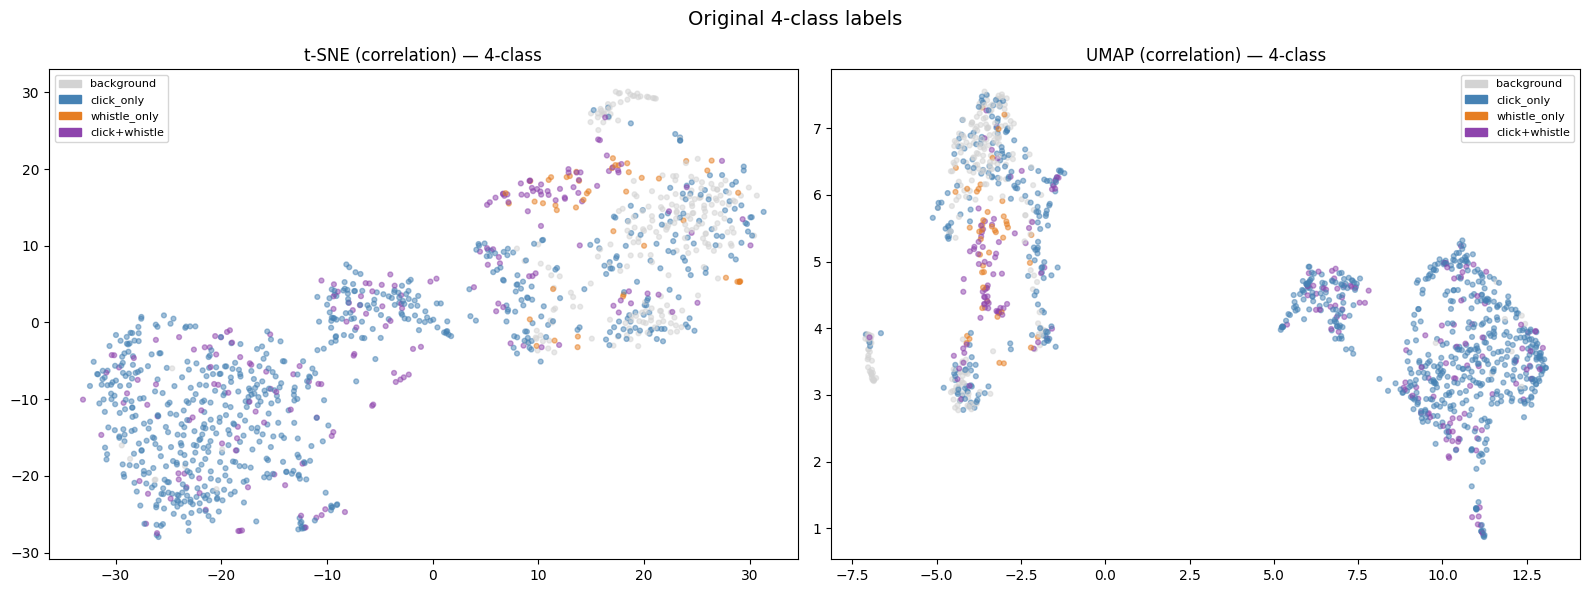

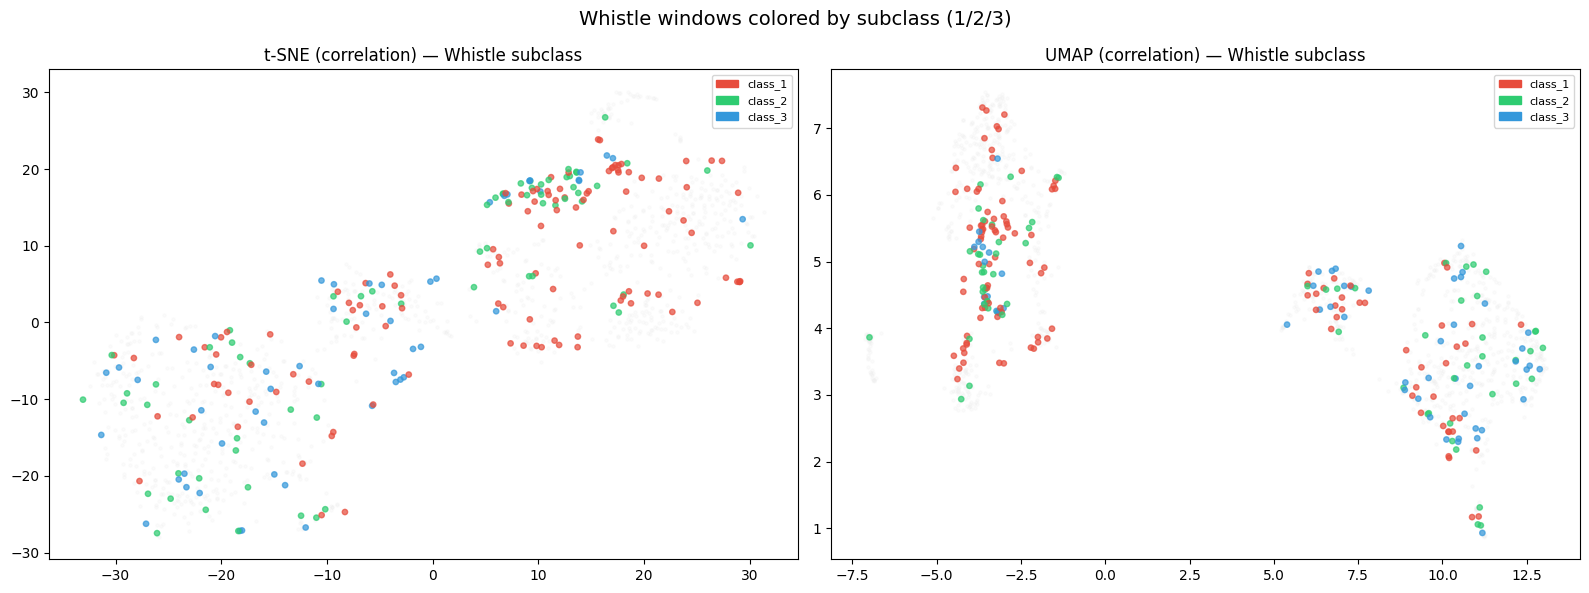

Whistle subclass distribution: {'class_1': 116, 'class_2': 69, 'class_3': 55}


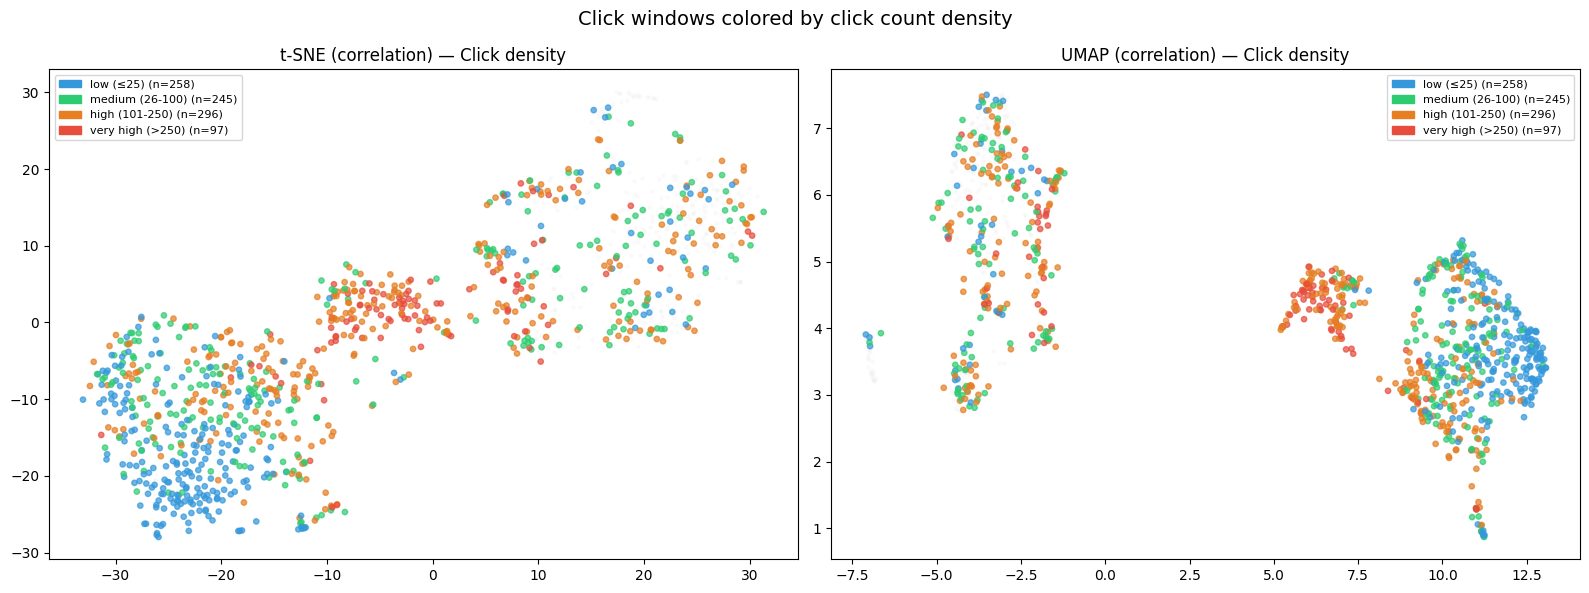

Click density distribution: {'high (101-250)': 296, 'low (≤25)': 258, 'medium (26-100)': 245, 'very high (>250)': 97}


: 

In [ ]:
#@title Granular UMAP & t-SNE — 4-class, whistle subclass, click density

import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# ── Use the same PCA-reduced data ────────────────────────────────────────────
# (reuse X_pca_red and best metric from previous cell, or recompute)
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)

# Pick best metric from previous run (or just use cosine)
metric = 'correlation'

print(f'Running t-SNE ({metric})...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='random', max_iter=1000, metric=metric,
            random_state=random_seed, verbose=0)
X_tsne = tsne.fit_transform(X_pca_red)

print(f'Running UMAP ({metric})...')
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2,
                     metric=metric, random_state=random_seed, verbose=False)
X_umap = reducer.fit_transform(X_pca_red)

alpha = 0.5
s = 12

# ═══════════════════════════════════════════════════════════════════════════════
# 1. ORIGINAL 4-CLASS
# ═══════════════════════════════════════════════════════════════════════════════
colors_4class = {
    'background': '#d3d3d3',
    'click_only': '#4682b4',
    'whistle_only': '#e67e22',
    'click+whistle': '#8e44ad',
}
c_4class = np.array([colors_4class[label] for label in y_clean])
patches_4class = [mpatches.Patch(color=v, label=k) for k, v in colors_4class.items()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c_4class, alpha=alpha, s=s)
ax1.set_title(f't-SNE ({metric}) — 4-class')
ax1.legend(handles=patches_4class, fontsize=8)
ax2.scatter(X_umap[:, 0], X_umap[:, 1], c=c_4class, alpha=alpha, s=s)
ax2.set_title(f'UMAP ({metric}) — 4-class')
ax2.legend(handles=patches_4class, fontsize=8)
plt.suptitle('Original 4-class labels', fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_umap_4class.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. WHISTLE SUBCLASS (only whistle windows, colored by subclass)
# ═══════════════════════════════════════════════════════════════════════════════
# Get the original windows_df rows that survived cleaning
# y_clean still has original 4-class labels
whistle_mask = np.isin(y_clean, ['whistle_only', 'click+whistle'])
whistle_subclasses_per_window = windows_df.loc[windows_df.index[whistle_mask], 'whistle_subclasses'].values

# Assign dominant subclass per window
def get_dominant_subclass(subs):
    if isinstance(subs, str):
        import ast
        subs = ast.literal_eval(subs)
    if not subs or len(subs) == 0:
        return 'none'
    from collections import Counter
    return f'class_{Counter(subs).most_common(1)[0][0]}'

whistle_sublabels = np.array([get_dominant_subclass(s) for s in whistle_subclasses_per_window])

colors_wsub = {
    'class_1': '#e74c3c',
    'class_2': '#2ecc71',
    'class_3': '#3498db',
    'none': '#999999',
}
c_wsub = np.array([colors_wsub.get(s, '#999999') for s in whistle_sublabels])
patches_wsub = [mpatches.Patch(color=v, label=k) for k, v in colors_wsub.items() if k in whistle_sublabels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot all points in gray first, then overlay whistle points
ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c='#eeeeee', alpha=0.2, s=5)
ax1.scatter(X_tsne[whistle_mask, 0], X_tsne[whistle_mask, 1], c=c_wsub, alpha=0.7, s=15)
ax1.set_title(f't-SNE ({metric}) — Whistle subclass')
ax1.legend(handles=patches_wsub, fontsize=8)

ax2.scatter(X_umap[:, 0], X_umap[:, 1], c='#eeeeee', alpha=0.2, s=5)
ax2.scatter(X_umap[whistle_mask, 0], X_umap[whistle_mask, 1], c=c_wsub, alpha=0.7, s=15)
ax2.set_title(f'UMAP ({metric}) — Whistle subclass')
ax2.legend(handles=patches_wsub, fontsize=8)

plt.suptitle('Whistle windows colored by subclass (1/2/3)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_umap_whistle_subclass.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Whistle subclass distribution: {dict(zip(*np.unique(whistle_sublabels, return_counts=True)))}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. CLICK DENSITY (only click windows, colored by count bins)
# ═══════════════════════════════════════════════════════════════════════════════
click_mask = np.isin(y_clean, ['click_only', 'click+whistle'])
click_counts_per_window = windows_df.loc[windows_df.index[click_mask], 'click_count'].values

# Bin into low/medium/high
def bin_clicks(count):
    if count <= 25:
        return 'low (≤25)'
    elif count <= 100:
        return 'medium (26-100)'
    elif count <= 250:
        return 'high (101-250)'
    else:
        return 'very high (>250)'

click_bins = np.array([bin_clicks(c) for c in click_counts_per_window])

colors_click = {
    'low (≤25)': '#3498db',
    'medium (26-100)': '#2ecc71',
    'high (101-250)': '#e67e22',
    'very high (>250)': '#e74c3c',
}
c_click = np.array([colors_click[b] for b in click_bins])
patches_click = [mpatches.Patch(color=v, label=f'{k} (n={np.sum(click_bins==k)})')
                 for k, v in colors_click.items() if k in click_bins]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c='#eeeeee', alpha=0.2, s=5)
ax1.scatter(X_tsne[click_mask, 0], X_tsne[click_mask, 1], c=c_click, alpha=0.7, s=15)
ax1.set_title(f't-SNE ({metric}) — Click density')
ax1.legend(handles=patches_click, fontsize=8)

ax2.scatter(X_umap[:, 0], X_umap[:, 1], c='#eeeeee', alpha=0.2, s=5)
ax2.scatter(X_umap[click_mask, 0], X_umap[click_mask, 1], c=c_click, alpha=0.7, s=15)
ax2.set_title(f'UMAP ({metric}) — Click density')
ax2.legend(handles=patches_click, fontsize=8)

plt.suptitle('Click windows colored by click count density', fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_umap_click_density.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Click density distribution: {dict(zip(*np.unique(click_bins, return_counts=True)))}')

In [1]:
# ── Remake: 3-class PCA scatter in thesis plotly style ───────────────────────
import numpy as np
import pandas as pd
import plotly.express as px

# Thesis palette
TEAL, AMBER, VIOLET = "#2f9292", "#EF9F27", "#7b5bc9"
GREY, FONT = "#5a5a5a", "Helvetica Neue, Arial, sans-serif"

save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA'


# 1. Fetch saved PCA coords
X_pca2 = np.load(f"{save_dir}/dim_red/coords_pca2.npy")          # shape (n, 2)

# 2. Class labels, with pretty display names
DISPLAY = {
    "background":      "Background",
    "click_only":      "Click only",
    "whistle_present": "Whistle present",
}
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')

# Remap whistle_only and click+whistle → whistle_present
label_remap = {
    'background':    'background',
    'click_only':    'click_only',
    'whistle_only':  'whistle_present',
    'click+whistle': 'whistle_present',
}
class_names = [DISPLAY[label_remap[lbl]] for lbl in y_clean]

# 3. Fixed colour map — reuse this EXACT dict in every thesis figure
COLOR_MAP = {
    "Whistle present": TEAL,
    "Click only":      AMBER,
    "Background":      VIOLET,        # swap to "#9aa0a6" for neutral-grey baseline
}
ORDER = ["Background", "Click only", "Whistle present"]  # background drawn first (bottom)

# 4. Explained variance — from full PCA (pca_full), PC1/PC2; same X_scaled as the 2D fit
var0, var1 = 19.79, 5.65
xlab, ylab = f"Component 1 ({var0:.1f}%)", f"Component 2 ({var1:.1f}%)"

# 5. Build figure
df_pca = pd.DataFrame({"PC1": X_pca2[:, 0], "PC2": X_pca2[:, 1], "class": class_names})

fig = px.scatter(
    df_pca, x="PC1", y="PC2", color="class",
    color_discrete_map=COLOR_MAP,
    category_orders={"class": ORDER},
)
fig.update_traces(marker=dict(size=6, opacity=0.65, line=dict(width=0)))
fig.update_layout(
    template="plotly_white",
    width=760, height=540,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family=FONT, size=12, color=GREY),

    margin=dict(l=70, r=170, t=50, b=60),
    legend=dict(title=dict(text="class", font=dict(size=12, color=GREY)),
                x=1.02, xanchor="left", y=1, yanchor="top",
                itemsizing="constant", font=dict(size=11, color=GREY),
                bgcolor="rgba(0,0,0,0)"),
    xaxis=dict(title=dict(text=xlab, font=dict(size=12, color=GREY)),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
    yaxis=dict(title=dict(text=ylab, font=dict(size=12, color=GREY)),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
)
fig.show()

# Optional static export (needs: pip install -U kaleido)
# fig.write_image(f"{save_dir}/dim_red/pca_2d_plotly.png", scale=3)